<a href="https://colab.research.google.com/github/busraparlakk/Auto-MPG/blob/main/karar_agac%C4%B1_gini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv("/content/top_rated_tv.csv")
df.head()

,first_air_date,name,overview,popularity,vote_average,vote_count,adult
0,2008-01-20,Breaking Bad,"Walter White, a New Mexico chemistry teacher, ...",122.1631,8.942,17539,False
1,2023-09-29,Frieren: Beyond Journey's End,Decades after her party defeated the Demon Kin...,86.7104,8.805,782,False
2,2015-11-06,Reply 1988,Take a nostalgic trip back to the late 1980s t...,15.7551,8.800,204,False
3,2005-02-21,Avatar: The Last Airbender,"In a war-torn world of elemental magic, a youn...",40.7230,8.756,4771,False
4,2021-11-06,Arcane,Amid the stark discord of twin cities Piltover...,36.7751,8.755,5821,False


In [5]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_air_date  2408 non-null   object 
 1   name            2408 non-null   object 
 2   overview        2386 non-null   object 
 3   popularity      2408 non-null   float64
 4   vote_average    2408 non-null   float64
 5   vote_count      2408 non-null   int64  
 6   adult           2408 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 115.4+ KB


,popularity,vote_average,vote_count
count,2408.000000,2408.000000,2408.000000
mean,18.127366,7.686588,958.321429
std,28.635238,0.573355,1702.554904
min,0.235500,3.436000,200.000000
25%,6.007075,7.312750,282.000000
50%,10.667450,7.719000,451.000000
75%,19.657925,8.117250,912.250000
max,629.248100,8.942000,26624.000000


In [6]:
df['target'] = (df['vote_average'] > 8).astype(int)

In [7]:
df = df.drop(['name','overview'], axis=1)

In [9]:
df.columns

Index(['first_air_date', 'popularity', 'vote_average', 'vote_count', 'adult',
       'target'],
      dtype='object')

In [10]:
df['first_air_date'] = pd.to_datetime(df['first_air_date'], errors='coerce')

df['year'] = df['first_air_date'].dt.year
df['month'] = df['first_air_date'].dt.month

df = df.drop('first_air_date', axis=1)

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
X = df.drop(['target','vote_average'], axis=1)
y = df['target']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion="entropy", max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7012448132780082


[Text(0.5446428571428571, 0.9, 'vote_count <= 561.5\nentropy = 0.904\nsamples = 1926\nvalue = [1311, 615]'),
 Text(0.2857142857142857, 0.7, 'popularity <= 9.008\nentropy = 0.737\nsamples = 1131\nvalue = [896.0, 235.0]'),
 Text(0.4151785714285714, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'popularity <= 8.183\nentropy = 0.643\nsamples = 672\nvalue = [562, 110]'),
 Text(0.07142857142857142, 0.3, 'popularity <= 6.12\nentropy = 0.667\nsamples = 621\nvalue = [513, 108]'),
 Text(0.03571428571428571, 0.1, 'entropy = 0.607\nsamples = 417\nvalue = [355, 62]'),
 Text(0.10714285714285714, 0.1, 'entropy = 0.77\nsamples = 204\nvalue = [158, 46]'),
 Text(0.21428571428571427, 0.3, 'year <= 2020.5\nentropy = 0.239\nsamples = 51\nvalue = [49, 2]'),
 Text(0.17857142857142858, 0.1, 'entropy = 0.0\nsamples = 43\nvalue = [43, 0]'),
 Text(0.25, 0.1, 'entropy = 0.811\nsamples = 8\nvalue = [6, 2]'),
 Text(0.42857142857142855, 0.5, 'year <= 2017.5\nentropy = 0.845\nsamples = 459\nvalue = [334, 125]'),
 T

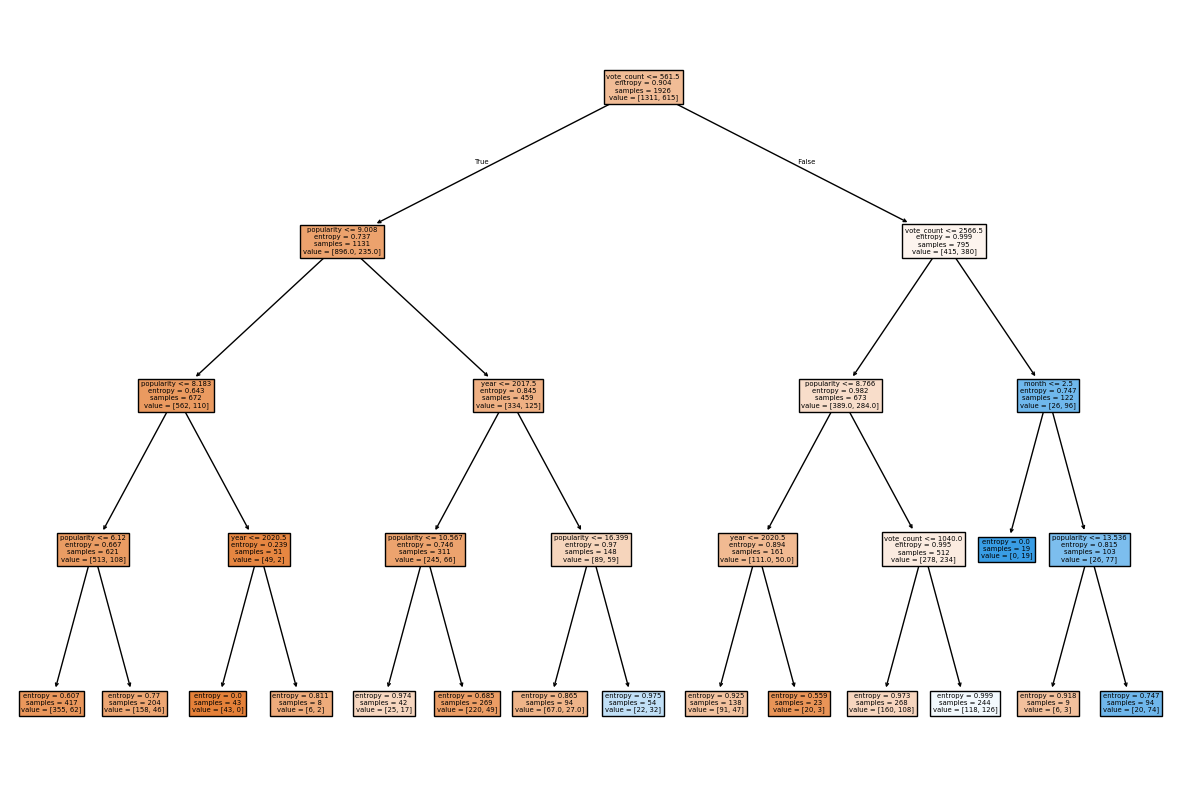

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, filled=True)